In [7]:
import importlib
import pandas as pd
import numpy as np
import pickle
import random

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

seed = 42
random.seed(seed)
np.random.seed(seed)

In [8]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

In [9]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [10]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

X_tr, X_val, X_test, Y_tr, Y_val, Y_test = utils.train_val_test_split(X, Y_resh, wavelengths, verbose=True)

X shape: (500, 9)
Y shape: (500, 6, 4205)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Comparison between Methods

In [11]:
mre_single = {}
mae_single = {}
mre_sel = {}
mae_sel = {}
mre_nodimred = {}
mae_nodimred = {}

mre_to_plot = {}
mae_to_plot = {}

with (
    open("gp_saves/testing_results/single_kernel/mre_per_wvl_log.pkl", "rb") as f1,
    open("gp_saves/testing_results/single_kernel/mae_per_wvl.pkl", "rb") as f2,
    open("gp_saves/testing_results/kernel_selection/mre_per_wvl_log.pkl", "rb") as f3,
    open("gp_saves/testing_results/kernel_selection/mae_per_wvl.pkl", "rb") as f4,
    open("gp_saves/testing_results/nodimred/mre_per_wvl_log.pkl", "rb") as f5,
    open("gp_saves/testing_results/nodimred/mae_per_wvl.pkl", "rb") as f6,
):
    mre_single = pickle.load(f1)
    mae_single = pickle.load(f2)
    mre_sel = pickle.load(f3)
    mae_sel = pickle.load(f4)
    mre_nodimred = pickle.load(f5)
    mae_nodimred = pickle.load(f6)

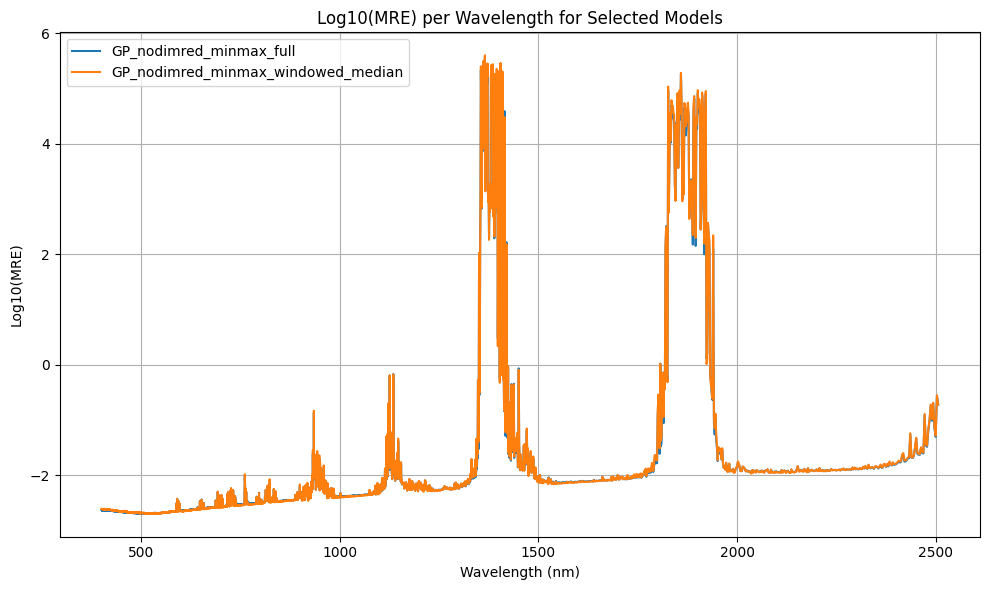

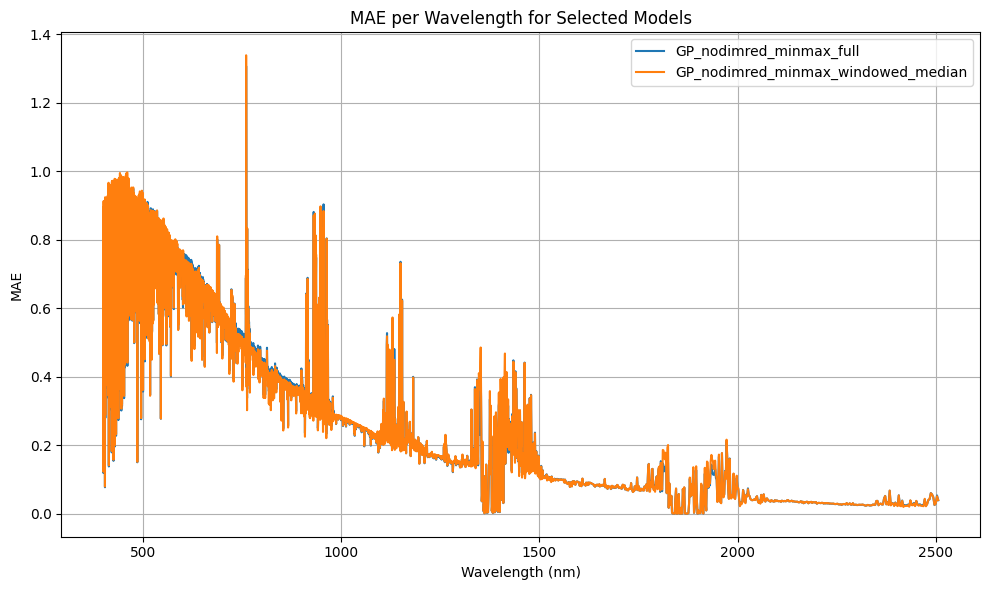

In [16]:
mre_to_plot = mre_nodimred.copy()
mae_to_plot = mae_nodimred.copy()

utils.show_multiple_experiments_errors(mre_to_plot, wavelengths, ylabel="Log10(MRE)", title="Log10(MRE) per Wavelength for Selected Models")
utils.show_multiple_experiments_errors(mae_to_plot, wavelengths, ylabel="MAE", title="MAE per Wavelength for Selected Models")